In [25]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.gridspec import GridSpec

from fiat_toolbox.well_being import CommunityUnit, WellBeingConfig, CapitalStock, IncomeConfig, SimulationConfig, Liquidity

In [26]:
housing_stock = CapitalStock(v=0.7, k=60000)
labor_stock = CapitalStock(v=0.4, k=5000000, recovery_time=5)
rental_stock = CapitalStock(v=0.7, k=50000, recovery_time=10)
income_config = IncomeConfig(i_0=48000, i_avg=48000, pi=0.15, c_i_ratio=1.0, c_L=5e-2)
sim_config = SimulationConfig(eta=1.5, rho=0.06, t_max=10, dt=1/52, currency="$", c_min=0.0, recovery_per=95.0)
liq = Liquidity(savings=10000)

config = WellBeingConfig(
    housing=housing_stock,
    labour_assets=labor_stock,
    rental_housing=rental_stock,
    income=income_config,
    simulation=sim_config,
    liquidity=liq
    
)

In [27]:
# Create a WellBeing object and optimize the lambda value
household = CommunityUnit(config=config)
household

CommunityUnit(
  housing = k=60000.0 v=0.7 recovery_time=None recovery_rate=None,
  rental_housing = k=50000.0 v=0.7 recovery_time=10.0 recovery_rate=0.299573227355399,
  labour_assets = k=5000000.0 v=0.4 recovery_time=5.0 recovery_rate=0.599146454710798,
  income = i_0=48000.0 i_avg=48000.0 pi=0.15 c_L=0.05 c_i_ratio=1.0 i_div=None,
  liquidity = savings=10000.0 insurance=0.0 support=0.0,
  simulation = eta=1.5 rho=0.06 t_max=10.0 dt=0.019230769230769232 currency='$' c_min=0.0 recovery_per=95.0
)

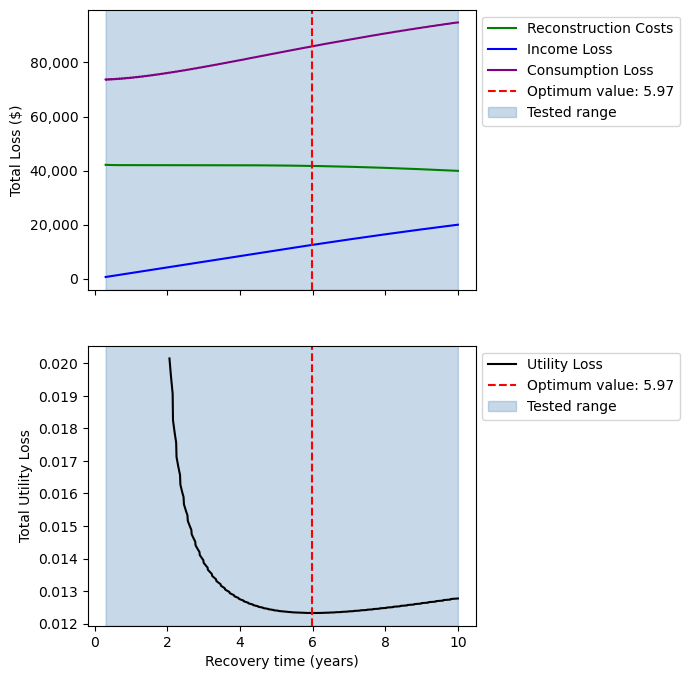

In [28]:
household.opt_lambda(method="trapezoid")
household.plot_opt_lambda(x_type="time");

In [29]:
household.get_losses("trapezoid")

Reconstruction Costs     41722.010146
Income Loss              12474.983131
Rental Income Loss       16648.729880
Labour Income Loss       24973.301234
Consumption Loss         85932.289192
Utility Loss                 0.012327
Wellbeing Loss          116675.603805
Asset Loss               42000.000000
Equity Weighted Loss     42000.000000
dtype: float64

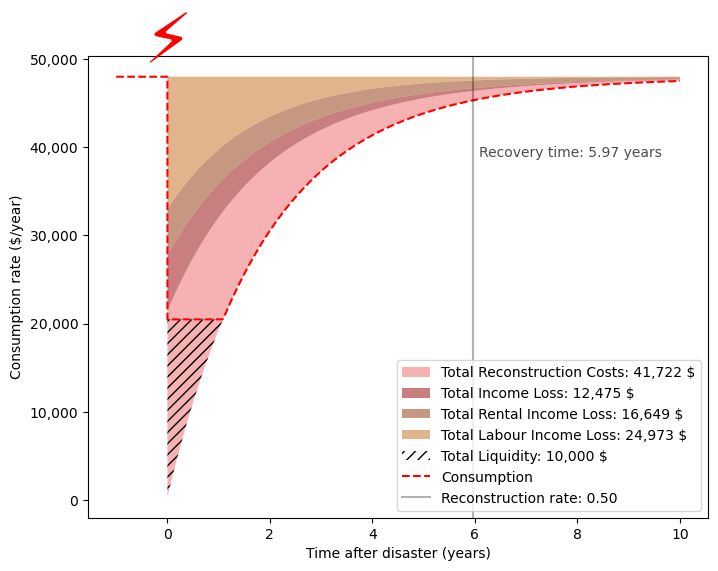

In [30]:
household.plot_consumption()